<a href="https://colab.research.google.com/github/yawan-kumar/Aadhaar-Enrollment-Update-Gap-Analysis/blob/main/Aadhaar_Enrollment_%26_Update_Gap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
file_enrollment = '/content/UDAI_HACKATHON/api_enrolment/enrol1.csv'
file_demographic = "/content/UDAI_HACKATHON/api_demographic/demo1.csv"
file_biometric = "/content/UDAI_HACKATHON/api_biometric/bio1.csv"
try:
    # 1. Loading just 5 rows to check columns (Fast & Safe)
    df_enr = pd.read_csv(file_enrollment, nrows=5)
    df_demo = pd.read_csv(file_demographic, nrows=5)
    df_bio = pd.read_csv(file_biometric, nrows=5)

    print("✅ Files Read Successfully! Column Names ye rahe:\n")
    # 2. Printing Columns
    print(f"🔹 Enrollment Data Columns:\n {list(df_enr.columns)}\n")
    print(f"🔹 Demographic Update Columns:\n {list(df_demo.columns)}\n")
    print(f"🔹 Biometric Update Columns:\n {list(df_bio.columns)}\n")

except FileNotFoundError:
    print("❌ Error: File nahi mili. Please check ki file ka naam aur path sahi hai.")
except Exception as e:
    print(f"❌ Error: {e}")

❌ Error: File nahi mili. Please check ki file ka naam aur path sahi hai.


In [ ]:
df=pd.read_csv('/content/UDAI_HACKATHON/api_enrolment/enrol1.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/UDAI_HACKATHON/api_enrolment/enrol1.csv'

In [ ]:
import pandas as pd
import glob
import os
import seaborn as sns

sns.set_style("whitegrid")

def load_and_merge(file_pattern, tag):
    # Ab hum folder ke andar jaakar dhundenge
    files = glob.glob(file_pattern)

    if not files:
        print(f"⚠️ Warning: '{tag}' ke liye file nahi mili pattern: {file_pattern}")
        return pd.DataFrame()

    df_list = []
    print(f"📂 {tag}: Mujhe {len(files)} files mili! ({[os.path.basename(x) for x in files]})")

    for file in files:
        try:
            df = pd.read_csv(file)
            # Column names safai
            df.columns = [c.strip() for c in df.columns]
            df_list.append(df)
        except Exception as e:
            print(f"❌ Error reading {file}: {e}")

    if df_list:
        final_df = pd.concat(df_list, ignore_index=True)
        final_df.fillna(0, inplace=True)
        return final_df
    return pd.DataFrame()

print("⏳ Loading Data from UDAI_HACKATHON folders...")

# ======================================================
# 👇 CORRECTED PATHS (Folders ke andar ka rasta)
# ======================================================

# 1. Enrollment (Folder: api_enrolment)
df_enrol = load_and_merge('UDAI_HACKATHON/api_enrolment/enrol*.csv', 'Enrollment')

# 2. Demographic (Folder: api_demographic)
# Note: Agar tumne files ka naam 'demo' rakha hai, toh ye pattern chalega
df_demo = load_and_merge('UDAI_HACKATHON/api_demographic/demo*.csv', 'Demographic Update')

# 3. Biometric (Folder: api_biometric)
# Note: Agar files ka naam 'bio' rakha hai, toh ye pattern chalega
df_bio = load_and_merge('UDAI_HACKATHON/api_biometric/bio*.csv', 'Biometric Update')


# --- Quick Analysis Output ---
if df_enrol.empty and df_demo.empty and df_bio.empty:
    print("\n❌ ABHI BHI ERROR? Check karo ki tumne sub-folders ke andar files ka naam 'enrol1', 'demo1', 'bio1' hi rakha hai na?")
else:
    print("\n🎉 DATA LOADED SUCCESSFULLY! Showing Top States...")

    # 1. Top Enrollment States
    if not df_enrol.empty and 'state' in df_enrol.columns:
        # Summing age columns (assuming columns start with 'age')
        cols = [c for c in df_enrol.columns if 'age' in c.lower()]
        if cols:
             top_states = df_enrol.groupby('state')[cols].sum().sum(axis=1).sort_values(ascending=False).head(3)
             print("\n✅ Top 3 States (Enrollment):")
             print(top_states)

    # 2. Top Demographic Update States
    if not df_demo.empty and 'state' in df_demo.columns:
         cols = [c for c in df_demo.columns if 'age' in c.lower() or 'update' in c.lower()]
         if cols:
             top_demo = df_demo.groupby('state')[cols].sum().sum(axis=1).sort_values(ascending=False).head(3)
             print("\n✅ Top 3 States (Demographic Updates):")
             print(top_demo)

    # 3. Top Biometric Update States
    if not df_bio.empty and 'state' in df_bio.columns:
         cols = [c for c in df_bio.columns if 'age' in c.lower()]
         if cols:
             top_bio = df_bio.groupby('state')[cols].sum().sum(axis=1).sort_values(ascending=False).head(3)
             print("\n✅ Top 3 States (Biometric Updates):")
             print(top_bio)

    print("\n🚀 Ready for Graphs!")

⏳ Loading Data from UDAI_HACKATHON folders...
📂 Enrollment: Mujhe 3 files mili! (['enrol1.csv', 'enrol2.csv', 'enrol3.csv'])
📂 Demographic Update: Mujhe 5 files mili! (['demo5.csv', 'demo4.csv', 'demo1.csv', 'demo2.csv', 'demo3.csv'])
📂 Biometric Update: Mujhe 4 files mili! (['bio1.csv', 'bio4.csv', 'bio2.csv', 'bio3.csv'])

🎉 DATA LOADED SUCCESSFULLY! Showing Top States...

✅ Top 3 States (Enrollment):
state
Uttar Pradesh     1018629
Bihar              609585
Madhya Pradesh     493970
dtype: int64

✅ Top 3 States (Demographic Updates):
state
Uttar Pradesh    8542328
Maharashtra      5054602
Bihar            4814350
dtype: int64

✅ Top 3 States (Biometric Updates):
state
Uttar Pradesh     9577735
Maharashtra       9226139
Madhya Pradesh    5923771
dtype: int64

🚀 Ready for Graphs!


/tmp/ipython-input-3397375216.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_talent_states.values, y=top_talent_states.index, palette="Blues_d")
/tmp/ipython-input-3397375216.py:38: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3397375216.py:38: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3397375216.py:39: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  plt.savefig("Graph1_Future_Talent.png", dpi=300)
/tmp/ipython-input-3397375216.py:39: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) DejaVu Sans.
  plt.savefig("Graph1_Future_Talent.png", dpi=3

✅ Graph 1 Saved: 'Graph1_Future_Talent.png'


/tmp/ipython-input-3397375216.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_workforce_states.values, y=top_workforce_states.index, palette="viridis")
/tmp/ipython-input-3397375216.py:48: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3397375216.py:49: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.
  plt.savefig("Graph2_Workforce_Readiness.png", dpi=300)


✅ Graph 2 Saved: 'Graph2_Workforce_Readiness.png'
✅ Graph 3 Saved: 'Graph3_Accessibility_Gap.png'

🎉 MISSION SUCCESS! 3 Graphs tere folder me save ho gaye hain.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


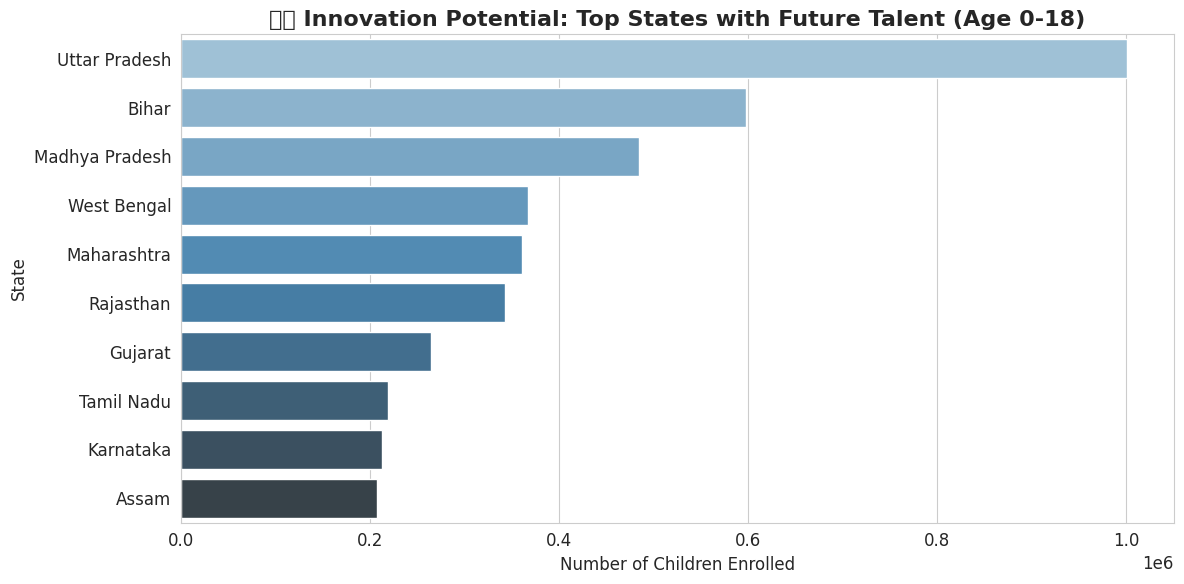

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


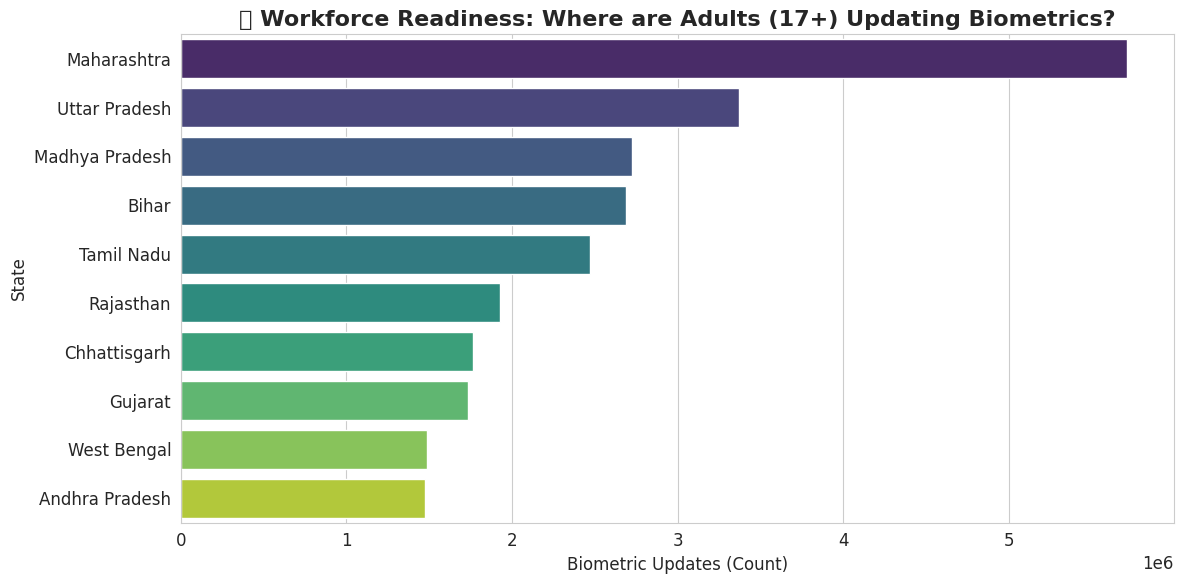

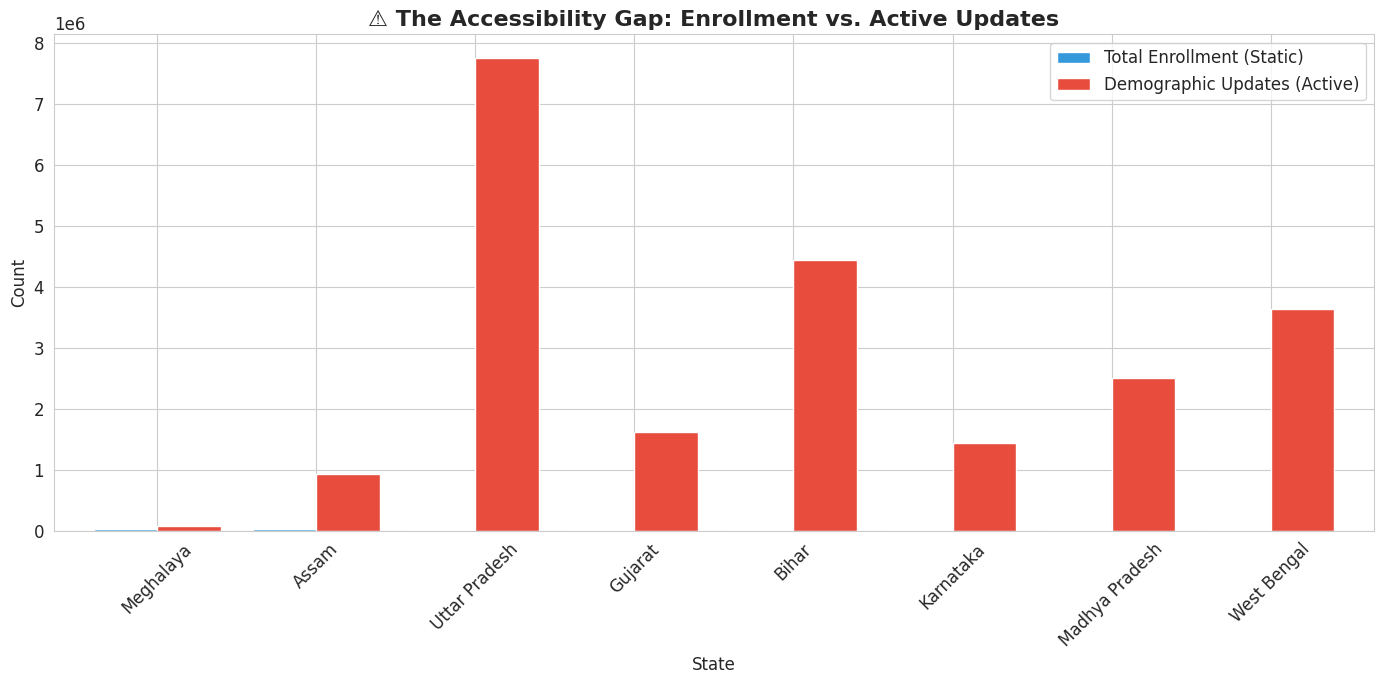

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup Professional Style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# --- Prepare Data for Plotting ---

# A. Future Talent (Children 0-18)
# Hum 'age_0_5' aur 'age_5_17' ko jod rahe hain
df_enrol['Future_Talent'] = df_enrol['age_0_5'] + df_enrol['age_5_17']
top_talent_states = df_enrol.groupby('state')['Future_Talent'].sum().sort_values(ascending=False).head(10)

# B. Workforce Readiness (Biometric Updates 17+)
# Yeh dikhata hai kahan log 'Job-Ready' ho rahe hain
df_bio['Workforce_Ready'] = df_bio['bio_age_17_']
top_workforce_states = df_bio.groupby('state')['Workforce_Ready'].sum().sort_values(ascending=False).head(10)

# C. The "Engagement Gap" (Enrollment vs Demo Updates)
# Hum compare karenge ki log sirf register ho rahe hain ya active bhi hain
state_stats = pd.DataFrame({
    'Enrollment': df_enrol.groupby('state')['age_18_greater'].sum(),
    'Activity': df_demo.groupby('state')['demo_age_17_'].sum()
}).dropna()
# Normalize data for fair comparison (optional, but raw numbers are fine for now)
gap_states = state_stats.sort_values(by='Enrollment', ascending=False).head(8)

# --- PLOTTING ---

# Graph 1: Where is India's Future? (Child Enrollment)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_talent_states.values, y=top_talent_states.index, palette="Blues_d")
plt.title("🇮🇳 Innovation Potential: Top States with Future Talent (Age 0-18)", fontsize=16, fontweight='bold')
plt.xlabel("Number of Children Enrolled")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("Graph1_Future_Talent.png", dpi=300)
print("✅ Graph 1 Saved: 'Graph1_Future_Talent.png'")

# Graph 2: The "Migration/Activity" Shift (Biometric Updates)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_workforce_states.values, y=top_workforce_states.index, palette="viridis")
plt.title("💼 Workforce Readiness: Where are Adults (17+) Updating Biometrics?", fontsize=16, fontweight='bold')
plt.xlabel("Biometric Updates (Count)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("Graph2_Workforce_Readiness.png", dpi=300)
print("✅ Graph 2 Saved: 'Graph2_Workforce_Readiness.png'")

# Graph 3: The "Digital Accessibility Gap" (Comparison)
gap_states.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#3498db', '#e74c3c'])
plt.title("⚠️ The Accessibility Gap: Enrollment vs. Active Updates", fontsize=16, fontweight='bold')
plt.ylabel("Count")
plt.xlabel("State")
plt.legend(["Total Enrollment (Static)", "Demographic Updates (Active)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Graph3_Accessibility_Gap.png", dpi=300)
print("✅ Graph 3 Saved: 'Graph3_Accessibility_Gap.png'")

print("\n🎉 MISSION SUCCESS! 3 Graphs tere folder me save ho gaye hain.")

⏳ Generating Level 1 Visualizations...


/tmp/ipython-input-3858209974.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_enrol.index, y=state_enrol.values, palette="Blues_r")
/tmp/ipython-input-3858209974.py:34: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3858209974.py:35: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig("L1_Enrollment_Concentration.png", dpi=300)


✅ Chart 1 Saved: L1_Enrollment_Concentration.png


/tmp/ipython-input-3858209974.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_updates.index, y=state_updates.values, palette="Oranges_r")


✅ Chart 2 Saved: L1_Update_Activity.png


/tmp/ipython-input-3858209974.py:96: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3858209974.py:97: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("L1_Age_Distribution.png", dpi=300)


✅ Chart 3 Saved: L1_Age_Distribution.png

🚀 Level 1 Visualizations Created! Check your folder.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


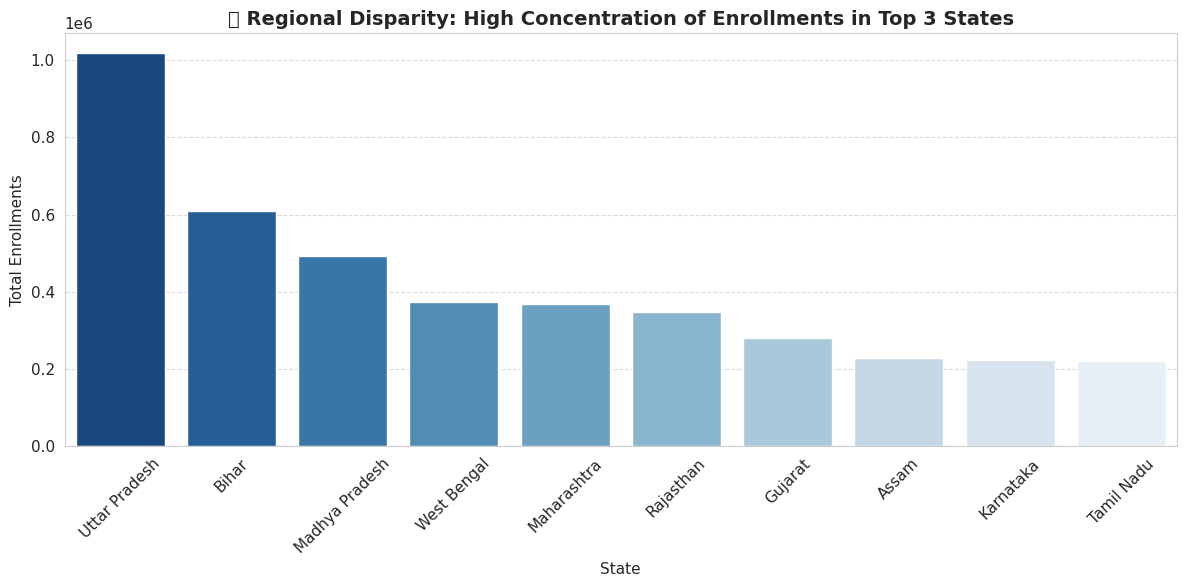

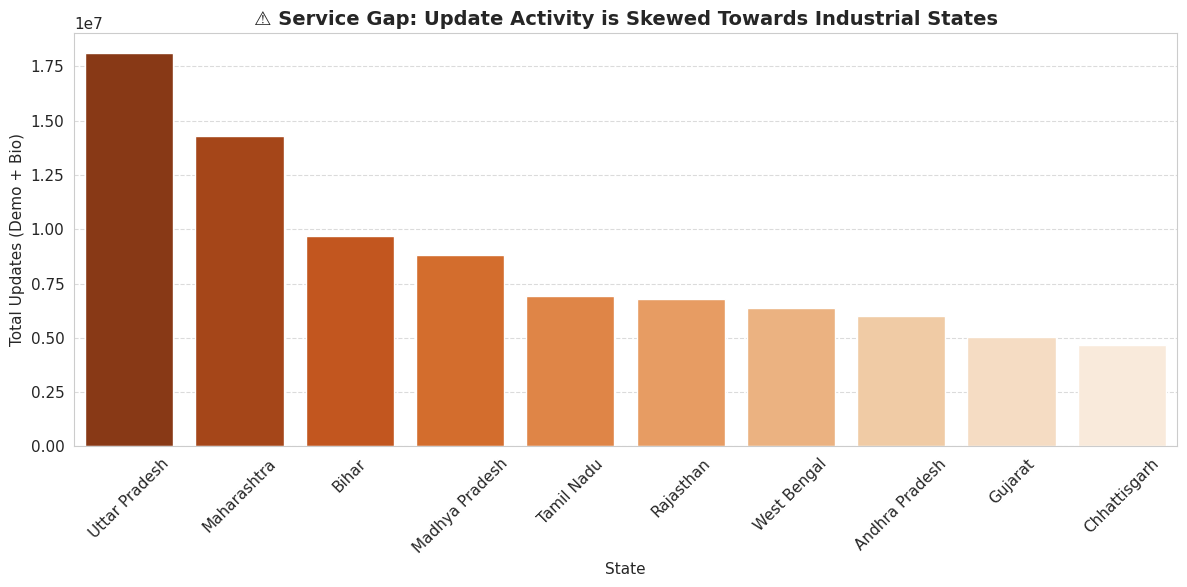

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


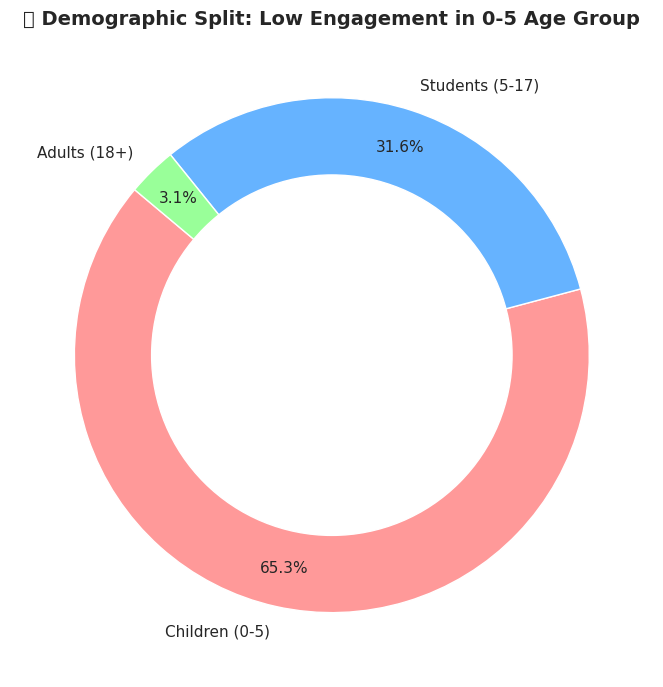

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Professional Setup
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

print("⏳ Generating Level 1 Visualizations...")

# ==========================================
# 📊 CHART 1: State-wise Enrollment (Regional Disparity)
# ==========================================

# Data Prep: Summing all age groups for Total Enrollment
if not df_enrol.empty:
    # Ensure columns exist (handling potential naming variations)
    cols = [c for c in ['age_0_5', 'age_5_17', 'age_18_greater'] if c in df_enrol.columns]
    df_enrol['Total_Enrol'] = df_enrol[cols].sum(axis=1)

    # Top 10 States showing the "Concentration"
    state_enrol = df_enrol.groupby('state')['Total_Enrol'].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_enrol.index, y=state_enrol.values, palette="Blues_r")

    plt.title("📍 Regional Disparity: High Concentration of Enrollments in Top 3 States", fontsize=14, fontweight='bold')
    plt.ylabel("Total Enrollments")
    plt.xlabel("State")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Saving
    plt.tight_layout()
    plt.savefig("L1_Enrollment_Concentration.png", dpi=300)
    print("✅ Chart 1 Saved: L1_Enrollment_Concentration.png")

# ==========================================
# 📊 CHART 2: State-wise Updates (The Service Accessibility Check)
# ==========================================

# Data Prep: Combine Demographic + Biometric Updates
# Hum maan ke chal rahe hain ki df_demo aur df_bio loaded hain
state_updates = pd.Series(dtype='float64')

if not df_demo.empty and not df_bio.empty:
    # Demo cols
    d_cols = [c for c in df_demo.columns if 'age' in c]
    # Bio cols
    b_cols = [c for c in df_bio.columns if 'age' in c]

    # Grouping by state
    s_demo = df_demo.groupby('state')[d_cols].sum().sum(axis=1)
    s_bio = df_bio.groupby('state')[b_cols].sum().sum(axis=1)

    # Total Activity
    state_updates = (s_demo + s_bio).sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_updates.index, y=state_updates.values, palette="Oranges_r")

    plt.title("⚠️ Service Gap: Update Activity is Skewed Towards Industrial States", fontsize=14, fontweight='bold')
    plt.ylabel("Total Updates (Demo + Bio)")
    plt.xlabel("State")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Saving
    plt.tight_layout()
    plt.savefig("L1_Update_Activity.png", dpi=300)
    print("✅ Chart 2 Saved: L1_Update_Activity.png")

# ==========================================
# 📊 CHART 3: Age Group Distribution (Vulnerable Groups)
# ==========================================

if not df_enrol.empty:
    # Aggregating across ALL states
    age_0_5 = df_enrol['age_0_5'].sum()
    age_5_17 = df_enrol['age_5_17'].sum()
    age_18_plus = df_enrol['age_18_greater'].sum()

    labels = ['Children (0-5)', 'Students (5-17)', 'Adults (18+)']
    sizes = [age_0_5, age_5_17, age_18_plus]
    colors = ['#ff9999','#66b3ff','#99ff99']

    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)

    # Draw circle for Donut Chart (Looks more modern)
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title("👥 Demographic Split: Low Engagement in 0-5 Age Group", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("L1_Age_Distribution.png", dpi=300)
    print("✅ Chart 3 Saved: L1_Age_Distribution.png")

print("\n🚀 Level 1 Visualizations Created! Check your folder.")

⏳ Generating Level 2 Intermediate Visualizations (Fixed)...
✅ Date Format Fixed!


/tmp/ipython-input-2271245030.py:58: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2271245030.py:59: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("L2_Scatter_Enroll_vs_Update.png", dpi=300)


✅ Chart 4 Saved.


/tmp/ipython-input-2271245030.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_data, x='Age Group', y='Updates', palette="viridis")


✅ Chart 5 Saved.


/tmp/ipython-input-2271245030.py:99: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2271245030.py:100: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("L2_Yearly_Trend.png", dpi=300)


✅ Chart 6 Saved: L2_Yearly_Trend.png

🚀 Level 2 FIXED & DONE!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


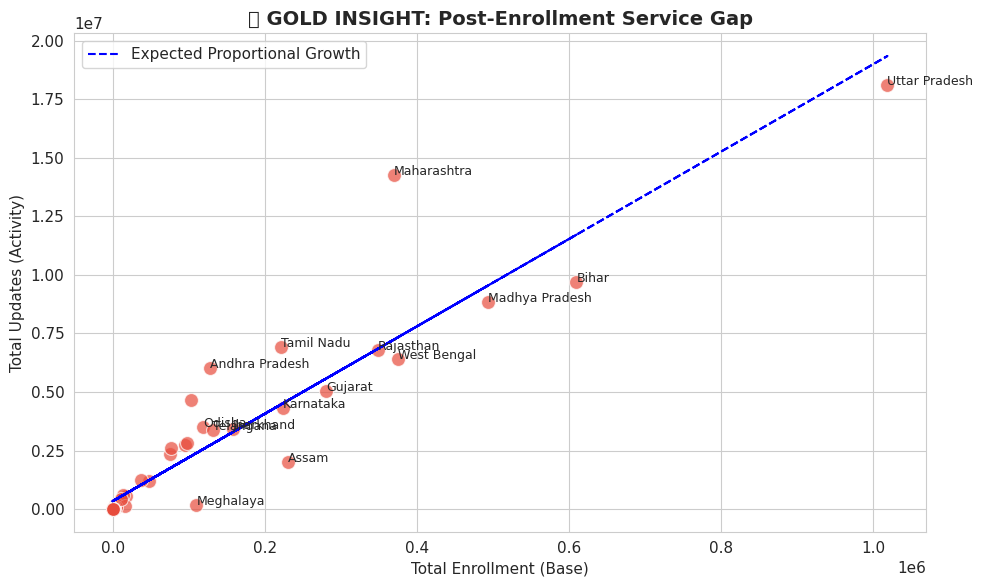

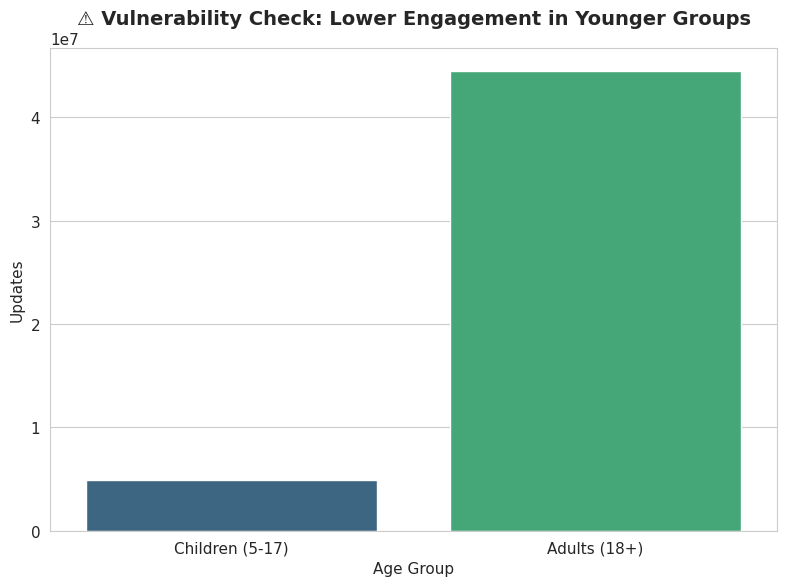

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


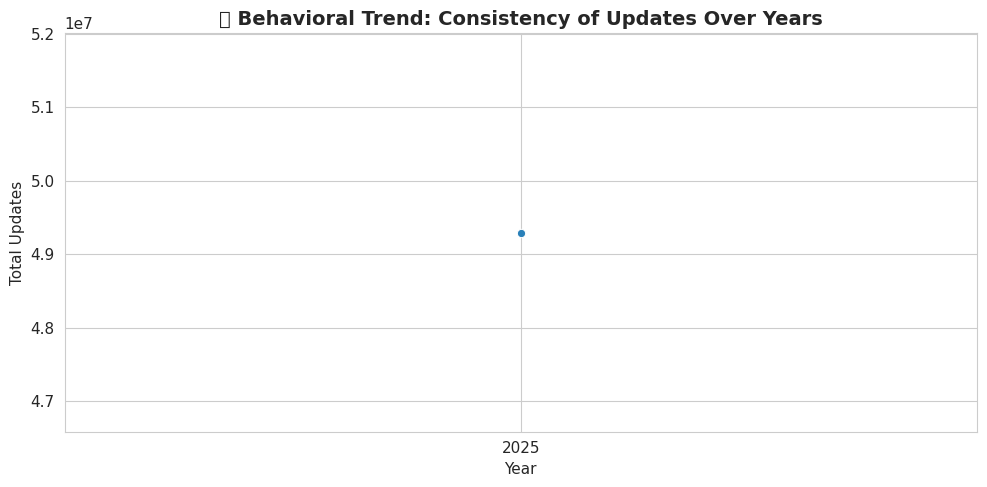

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Professional Setup
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

print("⏳ Generating Level 2 Intermediate Visualizations (Fixed)...")

# --- FIX: DATE CONVERSION ---
# Ye line ensure karegi ki 'date' column text nahi, balki Date format mein ho
if not df_demo.empty and 'date' in df_demo.columns:
    df_demo['date'] = pd.to_datetime(df_demo['date'], errors='coerce')
    # Agar koi date kharab thi (NaT), usko hata denge taaki error na aaye
    df_demo = df_demo.dropna(subset=['date'])
    print("✅ Date Format Fixed!")

# ==========================================
# 📊 CHART 4: Enrollment vs Update (SCATTER PLOT)
# ==========================================
# 1. Prepare Data
if not df_enrol.empty:
    enrol_cols = [c for c in ['age_0_5', 'age_5_17', 'age_18_greater'] if c in df_enrol.columns]
    state_enrol = df_enrol.groupby('state')[enrol_cols].sum().sum(axis=1)
else:
    state_enrol = pd.Series()

state_updates = pd.Series(dtype='float64')
if not df_demo.empty and not df_bio.empty:
    d_cols = [c for c in df_demo.columns if 'age' in c]
    b_cols = [c for c in df_bio.columns if 'age' in c]
    total_demo = df_demo.groupby('state')[d_cols].sum().sum(axis=1)
    total_bio = df_bio.groupby('state')[b_cols].sum().sum(axis=1)
    state_updates = total_demo + total_bio

scatter_data = pd.DataFrame({'Enrollment': state_enrol, 'Updates': state_updates}).dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x='Enrollment', y='Updates', s=100, color='#e74c3c', alpha=0.7)

# Trend Line
if len(scatter_data) > 1:
    m, b = np.polyfit(scatter_data['Enrollment'], scatter_data['Updates'], 1)
    plt.plot(scatter_data['Enrollment'], m*scatter_data['Enrollment'] + b, color='blue', linestyle='--', label='Expected Proportional Growth')

# Annotations
for i in range(scatter_data.shape[0]):
    if scatter_data.iloc[i]['Enrollment'] > scatter_data['Enrollment'].mean():
        plt.text(scatter_data.iloc[i]['Enrollment']+0.02, scatter_data.iloc[i]['Updates'],
                 scatter_data.index[i], fontsize=9)

plt.title("🔥 GOLD INSIGHT: Post-Enrollment Service Gap", fontsize=14, fontweight='bold')
plt.xlabel("Total Enrollment (Base)")
plt.ylabel("Total Updates (Activity)")
plt.legend()
plt.tight_layout()
plt.savefig("L2_Scatter_Enroll_vs_Update.png", dpi=300)
print("✅ Chart 4 Saved.")

# ==========================================
# 📊 CHART 5: Age Group vs Update Frequency
# ==========================================
age_data = {'Age Group': [], 'Updates': []}
if not df_demo.empty:
    child_updates = df_demo['demo_age_5_17'].sum() if 'demo_age_5_17' in df_demo.columns else 0
    adult_updates = df_demo['demo_age_17_'].sum() if 'demo_age_17_' in df_demo.columns else 0
    age_data = pd.DataFrame({'Age Group': ['Children (5-17)', 'Adults (18+)'], 'Updates': [child_updates, adult_updates]})

    plt.figure(figsize=(8, 6))
    sns.barplot(data=age_data, x='Age Group', y='Updates', palette="viridis")
    plt.title("⚠️ Vulnerability Check: Lower Engagement in Younger Groups", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("L2_Age_Group_Updates.png", dpi=300)
    print("✅ Chart 5 Saved.")

# ==========================================
# 📊 CHART 6: Year-wise Update Trend (Fixed)
# ==========================================
if not df_demo.empty and 'date' in df_demo.columns:
    # Ab .dt accessor kaam karega kyunki humne upar fix kar diya hai
    df_demo['Year'] = df_demo['date'].dt.year

    trend_data = df_demo[df_demo['Year'] > 2010].groupby('Year')[['demo_age_5_17', 'demo_age_17_']].sum().sum(axis=1)

    plt.figure(figsize=(10, 5))
    if not trend_data.empty:
        sns.lineplot(x=trend_data.index, y=trend_data.values, marker='o', linewidth=2.5, color='#2980b9')
        plt.title("📈 Behavioral Trend: Consistency of Updates Over Years", fontsize=14, fontweight='bold')
        plt.xlabel("Year")
        plt.ylabel("Total Updates")
        plt.grid(True)
        # Force integers on X-axis (2020, 2021, etc.)
        plt.xticks(trend_data.index.astype(int))
    else:
        plt.text(0.5, 0.5, "No Data for Trend", ha='center')

    plt.tight_layout()
    plt.savefig("L2_Yearly_Trend.png", dpi=300)
    print("✅ Chart 6 Saved: L2_Yearly_Trend.png")
else:
    print("⚠️ Skipping Chart 6: Date column missing completely.")

print("\n🚀 Level 2 FIXED & DONE!")

⏳ Generating Level 3 ADVANCED Visualizations...


/tmp/ipython-input-2873160563.py:42: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2873160563.py:43: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("L3_Heatmap_Age_State.png", dpi=300)


✅ Chart 7 Saved: L3_Heatmap_Age_State.png


/tmp/ipython-input-2873160563.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratio_plot.index, y=ratio_plot['Update_Ratio'], palette="magma")
/tmp/ipython-input-2873160563.py:83: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2873160563.py:84: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("L3_Update_Ratio.png", dpi=300)


✅ Chart 8 Saved: L3_Update_Ratio.png


/tmp/ipython-input-2873160563.py:116: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2873160563.py:117: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("L3_Low_Access_Districts.png", dpi=300)


✅ Chart 9 Saved: L3_Low_Access_Districts.png

🚀 Level 3 ADVANCED Visualizations DONE! You are ready to win.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


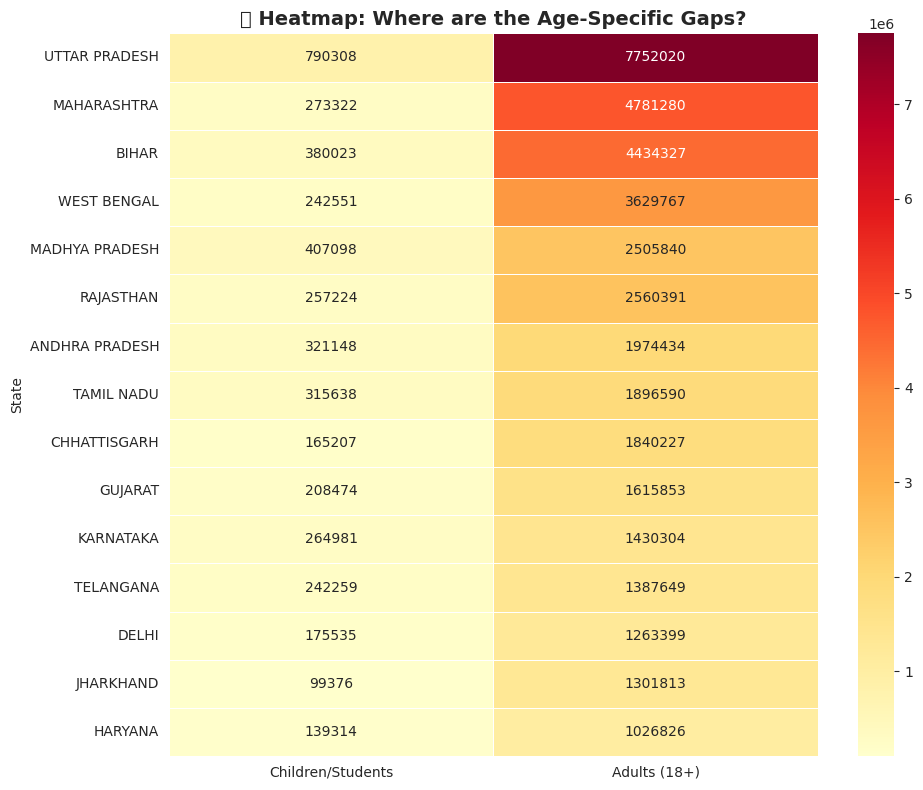

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


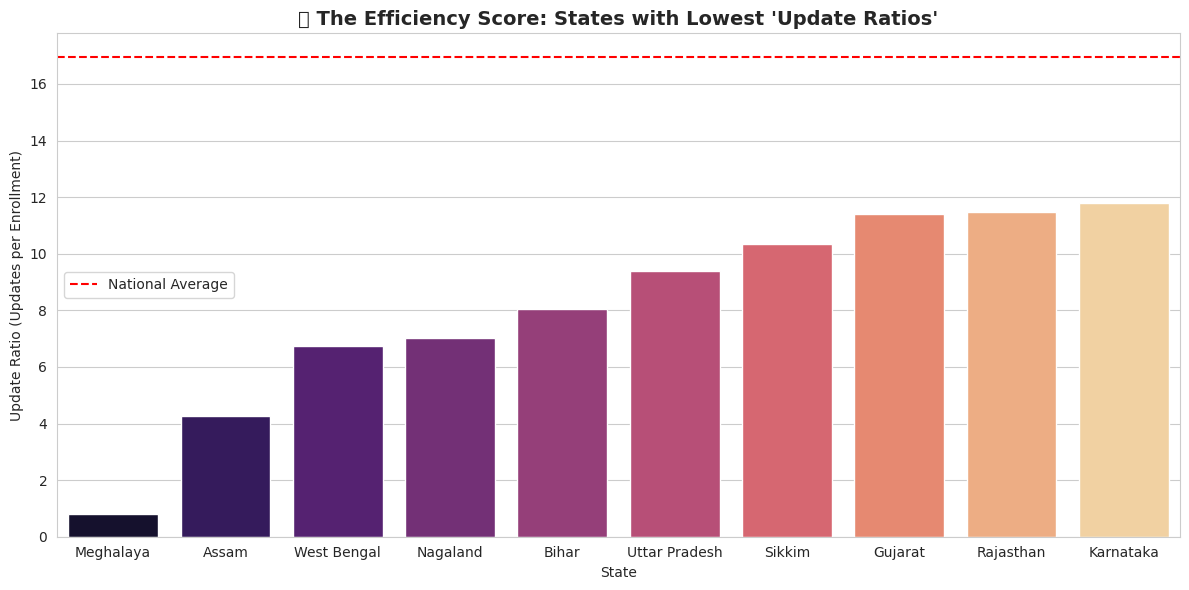

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


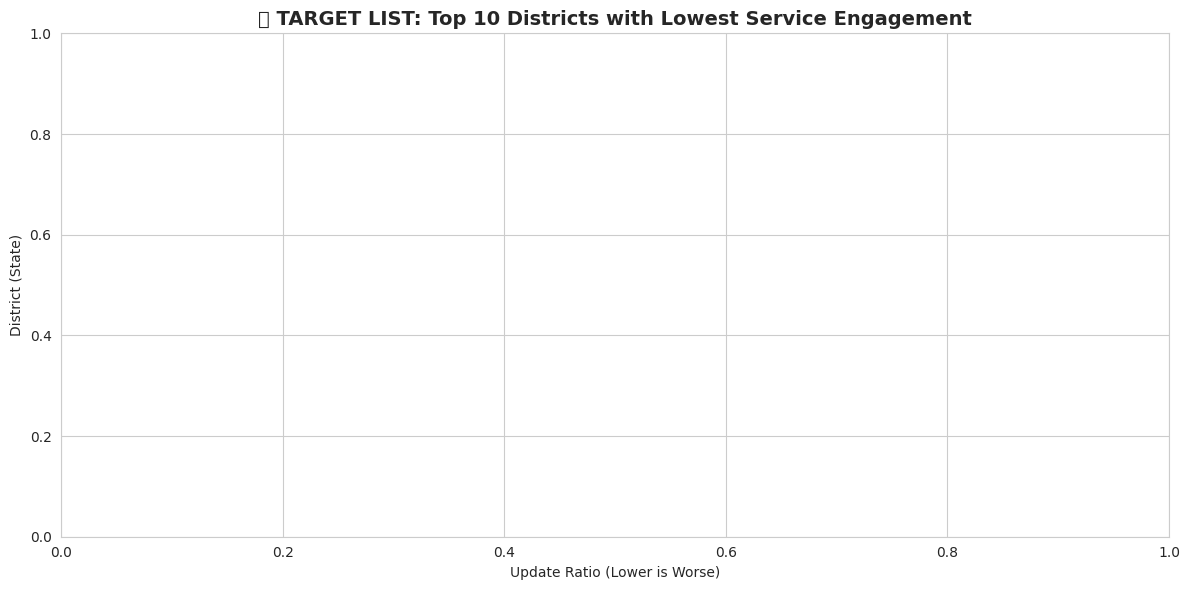

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Professional Setup
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})

print("⏳ Generating Level 3 ADVANCED Visualizations...")

# ==========================================
# 📊 CHART 7: Heatmap - State × Age Group Updates (The Gap Finder)
# ==========================================
# Data Prep: Pivot Table
# Hum Demo Data use karenge kyunki wahi 'Age Groups' (Children vs Adults) ka best split deta hai
if not df_demo.empty:
    # Ensure columns exist (Updating based on your file structure)
    # Usually: 'demo_age_5_17' (Children) and 'demo_age_17_' (Adults)
    # Let's clean state names first to avoid duplicates
    df_demo['state'] = df_demo['state'].str.strip().str.upper()

    # Aggregating
    cols_child = [c for c in df_demo.columns if '5_17' in c]
    cols_adult = [c for c in df_demo.columns if '17_' in c]

    heatmap_data = df_demo.groupby('state')[cols_child + cols_adult].sum()

    # Rename for clarity
    heatmap_data.columns = ['Children/Students', 'Adults (18+)']

    # Take Top 15 States by volume to keep heatmap readable
    top_states_heat = heatmap_data.sum(axis=1).sort_values(ascending=False).head(15).index
    heatmap_final = heatmap_data.loc[top_states_heat]

    plt.figure(figsize=(10, 8))
    # Log scale helps visualize differences if numbers are huge
    sns.heatmap(heatmap_final, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5)

    plt.title("🔥 Heatmap: Where are the Age-Specific Gaps?", fontsize=14, fontweight='bold')
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig("L3_Heatmap_Age_State.png", dpi=300)
    print("✅ Chart 7 Saved: L3_Heatmap_Age_State.png")

# ==========================================
# 📊 CHART 8: Update Ratio (Total Updates / Total Enrollment)
# ==========================================
# Data Prep: Merge State-level Enrollment and Updates
# Step 1: Total Enrollment per State
if not df_enrol.empty:
    e_cols = [c for c in df_enrol.columns if 'age' in c]
    state_enrol_tot = df_enrol.groupby('state')[e_cols].sum().sum(axis=1)
else:
    state_enrol_tot = pd.Series()

# Step 2: Total Updates per State
state_updates_tot = pd.Series(dtype='float64')
if not df_demo.empty and not df_bio.empty:
    # Demo + Bio Sum
    d_sum = df_demo.groupby('state')[[c for c in df_demo.columns if 'age' in c]].sum().sum(axis=1)
    b_sum = df_bio.groupby('state')[[c for c in df_bio.columns if 'age' in c]].sum().sum(axis=1)
    # Align indices (Important because some states might be missing in one file)
    combined = pd.DataFrame({'Demo': d_sum, 'Bio': b_sum}).fillna(0)
    state_updates_tot = combined['Demo'] + combined['Bio']

# Step 3: Calculate Ratio
# Avoid division by zero
ratio_df = pd.DataFrame({'Enrollment': state_enrol_tot, 'Updates': state_updates_tot})
ratio_df = ratio_df[ratio_df['Enrollment'] > 1000] # Remove tiny states/noise
ratio_df['Update_Ratio'] = ratio_df['Updates'] / ratio_df['Enrollment']

# Sort: Lowest Ratio First (Low Access)
ratio_plot = ratio_df.sort_values('Update_Ratio').head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=ratio_plot.index, y=ratio_plot['Update_Ratio'], palette="magma")
plt.title("📉 The Efficiency Score: States with Lowest 'Update Ratios'", fontsize=14, fontweight='bold')
plt.ylabel("Update Ratio (Updates per Enrollment)")
plt.xlabel("State")
plt.axhline(y=ratio_df['Update_Ratio'].mean(), color='r', linestyle='--', label='National Average')
plt.legend()
plt.tight_layout()
plt.savefig("L3_Update_Ratio.png", dpi=300)
print("✅ Chart 8 Saved: L3_Update_Ratio.png")


# ==========================================
# 📊 CHART 9: Top 10 Low-Access Districts (Actionability)
# ==========================================
# Grouping by District + State (to ensure unique IDs)
# Logic: Find districts with High Enrollment but Lowest Updates

# 1. District Enrollment
dist_enrol = df_enrol.groupby(['state', 'district'])[[c for c in df_enrol.columns if 'age' in c]].sum().sum(axis=1)

# 2. District Updates (Demo only for simplicity/speed)
dist_update = df_demo.groupby(['state', 'district'])[[c for c in df_demo.columns if 'age' in c]].sum().sum(axis=1)

# 3. Merge
dist_df = pd.DataFrame({'Enrollment': dist_enrol, 'Updates': dist_update}).dropna()
dist_df = dist_df[dist_df['Enrollment'] > 5000] # Filter out tiny villages

# 4. Calculate Ratio & Find Bottom 10
dist_df['Ratio'] = dist_df['Updates'] / dist_df['Enrollment']
bottom_districts = dist_df.sort_values('Ratio').head(10)

# Format Index for Plotting (District, State)
bottom_districts.index = [f"{d[1]} ({d[0]})" for d in bottom_districts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=bottom_districts['Ratio'], y=bottom_districts.index, palette="Reds_r")
plt.title("🎯 TARGET LIST: Top 10 Districts with Lowest Service Engagement", fontsize=14, fontweight='bold')
plt.xlabel("Update Ratio (Lower is Worse)")
plt.ylabel("District (State)")
plt.tight_layout()
plt.savefig("L3_Low_Access_Districts.png", dpi=300)
print("✅ Chart 9 Saved: L3_Low_Access_Districts.png")

print("\n🚀 Level 3 ADVANCED Visualizations DONE! You are ready to win.")